In [4]:
import xarray as xr
ds = xr.open_dataset("../../easy_inference/outputs_24h/prediction.nc")
print(ds)

<xarray.Dataset> Size: 10GB
Dimensions:                (sample: 1, input_time: 2, prediction_time: 6,
                            channel: 13, y: 4096, x: 4096)
Dimensions without coordinates: sample, input_time, prediction_time, channel,
                                y, x
Data variables: (12/30)
    sample_id              (sample) int32 4B ...
    input_timestamps       (sample, input_time) |S32 64B ...
    prediction_timestamps  (sample, prediction_time) |S32 192B ...
    channel_names          (channel) |S8 104B ...
    aia94                  (sample, prediction_time, y, x) float32 403MB ...
    gt_aia94               (sample, prediction_time, y, x) float32 403MB ...
    ...                     ...
    hmi_by                 (sample, prediction_time, y, x) float32 403MB ...
    gt_hmi_by              (sample, prediction_time, y, x) float32 403MB ...
    hmi_bz                 (sample, prediction_time, y, x) float32 403MB ...
    gt_hmi_bz              (sample, prediction_time, y, 

In [2]:
print(ds.data_vars.keys()) 

KeysView(Data variables:
    sample_id              (sample) int32 4B ...
    input_timestamps       (sample, input_time) |S32 64B ...
    prediction_timestamps  (sample, prediction_time) |S32 192B ...
    channel_names          (channel) |S8 104B ...
    aia94                  (sample, prediction_time, y, x) float32 403MB ...
    gt_aia94               (sample, prediction_time, y, x) float32 403MB ...
    aia131                 (sample, prediction_time, y, x) float32 403MB ...
    gt_aia131              (sample, prediction_time, y, x) float32 403MB ...
    aia171                 (sample, prediction_time, y, x) float32 403MB ...
    gt_aia171              (sample, prediction_time, y, x) float32 403MB ...
    aia193                 (sample, prediction_time, y, x) float32 403MB ...
    gt_aia193              (sample, prediction_time, y, x) float32 403MB ...
    aia211                 (sample, prediction_time, y, x) float32 403MB ...
    gt_aia211              (sample, prediction_time, y,

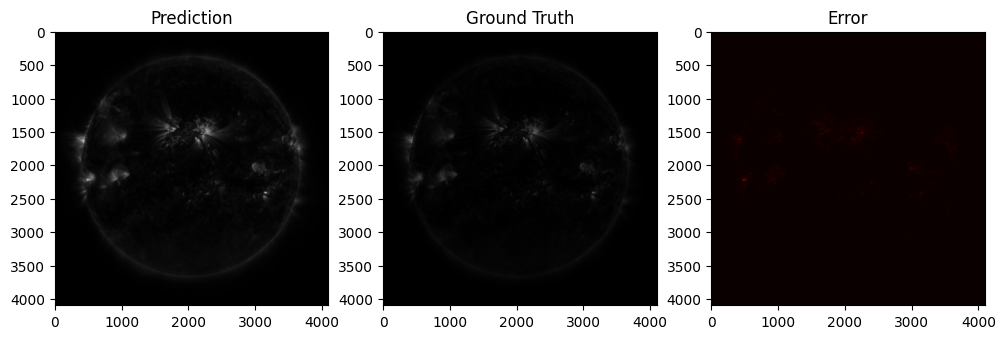

In [6]:
import matplotlib.pyplot as plt

pred = ds["aia171"][0, 0].values
gt   = ds["gt_aia171"][0, 0].values

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(pred, cmap="gray")
plt.title("Prediction")

plt.subplot(1,3,2)
plt.imshow(gt, cmap="gray")
plt.title("Ground Truth")

plt.subplot(1,3,3)
plt.imshow(abs(pred - gt), cmap="hot")
plt.title("Error")

plt.show()

In [4]:
t = 0
pred = ds["aia94"][0,t].values
gt = ds["gt_aia94"][0,t].values
error = pred-gt

/tmp/ipykernel_89474/4004444083.py:7: RuntimeWarning: invalid value encountered in log1p
  pred_vis = np.log1p(pred)


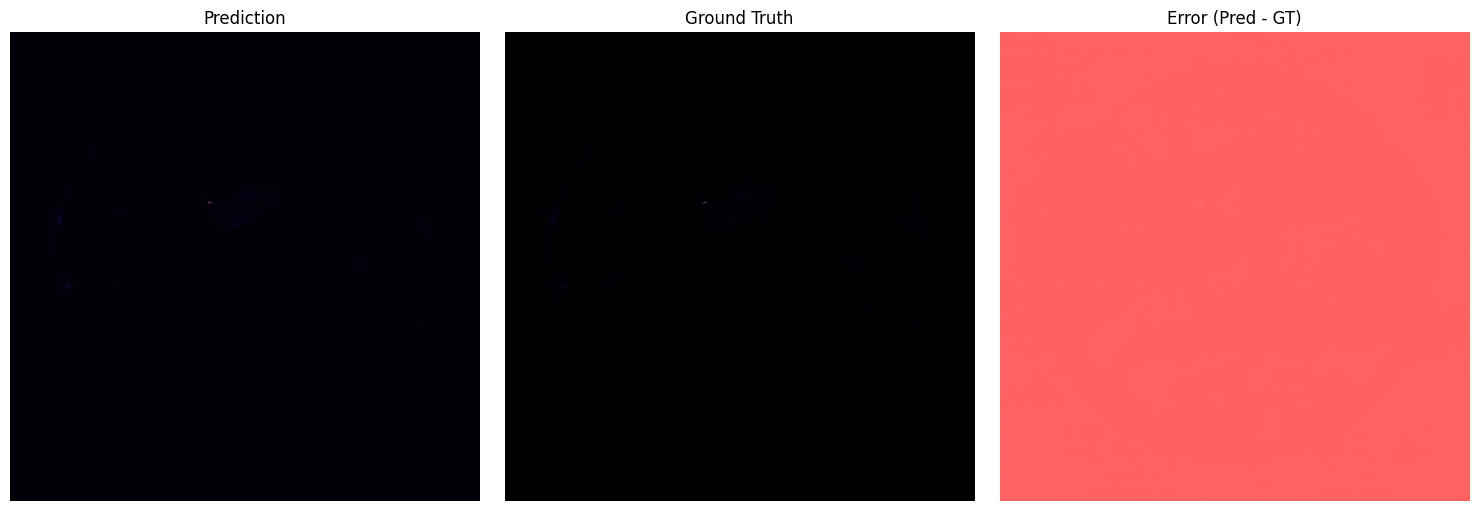

In [5]:
import matplotlib.pyplot as plt
import numpy as np


fig, axes = plt.subplots(1, 3, figsize=(15, 5))

pred_vis = np.log1p(pred)
gt_vis   = np.log1p(gt)

vmin = min(pred_vis.min(), gt.min())
vmax = max(pred_vis.max(), gt.max())

axes[0].imshow(pred, cmap="inferno", vmin=vmin, vmax=vmax)
axes[1].imshow(gt,   cmap="inferno", vmin=vmin, vmax=vmax)

axes[0].imshow(pred, cmap="inferno")
axes[0].set_title("Prediction")

axes[1].imshow(gt, cmap="inferno")
axes[1].set_title("Ground Truth")

axes[2].imshow(error, cmap="bwr")
axes[2].set_title("Error (Pred - GT)")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [6]:
channels = ["aia94", "aia131", "aia171","aia193","aia335","aia1600", "hmi_bx", "hmi_by", "hmi_bz", "hmi_m"]


# t = 0
# n = len(channels)

# fig, axes = plt.subplots(n, 3, figsize=(12, 4*n))

# for i, ch in enumerate(channels):
#     pred = ds[ch][0, t].values
#     gt   = ds[f"gt_{ch}"][0, t].values

#     if ((pred <= 0).any()):
#         pred_vis = np.log1p(np.clip(pred, 0, None))
#         gt_vis   = np.log1p(np.clip(gt,   0, None))
#     else:
#         pred_vis = pred
#         gt_vis   = gt
#     error = pred-gt

#     vmin = min(pred_vis.min(), gt_vis.min())
#     vmax = max(pred_vis.max(), gt_vis.max())

#     axes[i, 0].imshow(pred_vis, cmap="inferno", vmin=vmin, vmax=vmax)
#     axes[i, 0].set_title(f"{ch} Prediction")

#     axes[i, 1].imshow(gt_vis, cmap="inferno", vmin=vmin, vmax=vmax)
#     axes[i, 1].set_title(f"{ch} Ground Truth")

#     err_max = np.percentile(np.abs(error), 99)
#     axes[i, 2].imshow(error, cmap="bwr", vmin=-err_max, vmax=err_max)
#     axes[i, 2].set_title(f"{ch} Error")

#     for j in range(3):
#         axes[i, j].axis("off")

# plt.tight_layout()
# plt.show()

In [5]:
groups = {
    "aia": ["aia94", "aia131", "aia171", "aia193", "aia335", "aia1600"],
    "hmi": ["hmi_bx", "hmi_by", "hmi_bz", "hmi_m"]
}

In [14]:
def plot_timestep(ds, channels, t, suffix=""):

    n = len(channels)
    fig, axes = plt.subplots(n, 3, figsize=(12, 2*n))

    for i, ch in enumerate(channels):
        pred = ds[ch][0, t].values
        gt   = ds[f"gt_{ch}"][0, t].values

        if ch.startswith("aia"):
            pred_vis = np.log1p(np.clip(pred, 0, None))
            gt_vis   = np.log1p(np.clip(gt,   0, None))
            cmap_main = "inferno"

            vmin = min(pred_vis.min(), gt_vis.min())
            vmax = max(pred_vis.max(), gt_vis.max())
        elif ch == "hmi_m":
            pred_vis = pred
            gt_vis   = gt
            cmap_main = "inferno"
            vmax = np.percentile(np.concatenate([pred.ravel(), gt.ravel()]), 99)
            vmin = 0

        else:  # HMI
            scale = np.percentile(np.abs(np.concatenate([pred.ravel(), gt.ravel()])), 95)
            pred_vis = pred
            gt_vis   = gt
            cmap_main = "RdBu_r"

            vmin = -scale
            vmax = scale

        # TRUE error
        error = pred - gt
        err_max = np.percentile(np.abs(error), 95)

        axes[i, 0].imshow(pred_vis, cmap=cmap_main, vmin=vmin, vmax=vmax)
        axes[i, 0].set_title(f"{ch} Prediction")

        axes[i, 1].imshow(gt_vis, cmap=cmap_main, vmin=vmin, vmax=vmax)
        axes[i, 1].set_title(f"{ch} Ground Truth")

        axes[i, 2].imshow(error, cmap="RdBu_r", vmin=-err_max, vmax=err_max)
        axes[i, 2].set_title(f"{ch} Error")

        for j in range(3):
            axes[i, j].axis("off")

    plt.suptitle(f"Timestep t={t}", fontsize=16)
    plt.tight_layout(pad=2.5)
    fig.savefig(
        f"timestep_t{t}{suffix}.png",
        dpi=100,
        bbox_inches="tight",
        facecolor="white"
    )
    plt.show()
    

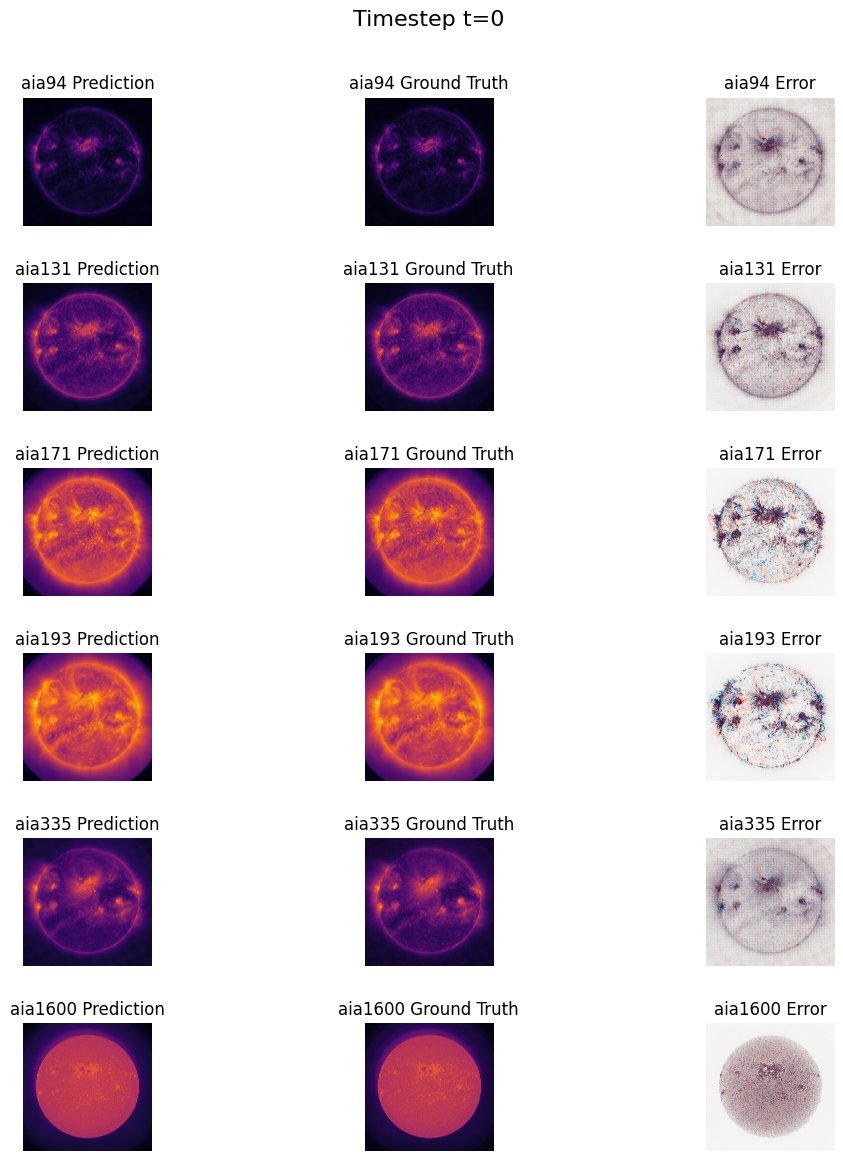

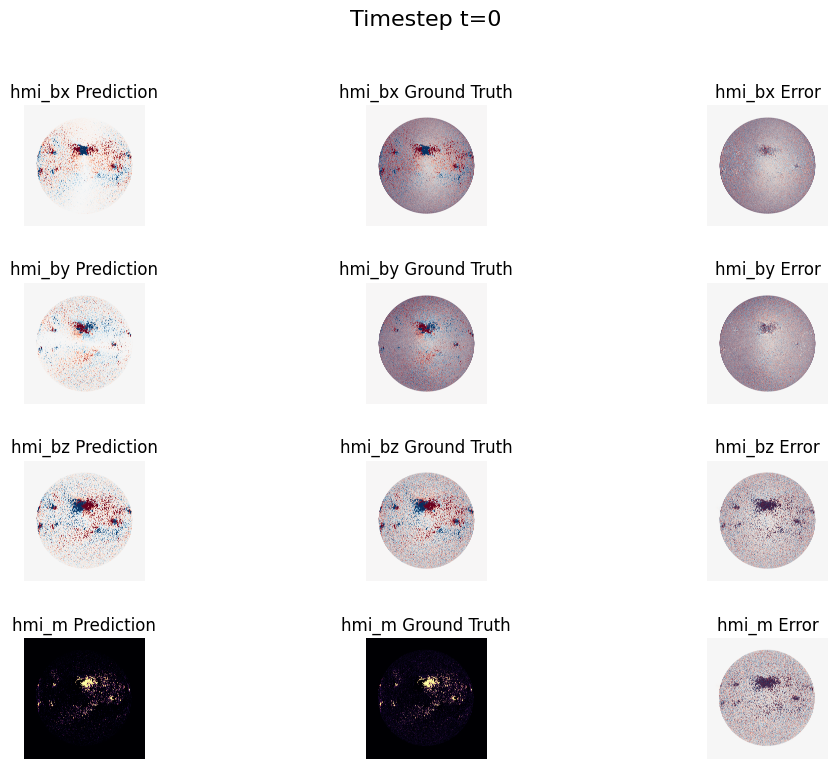

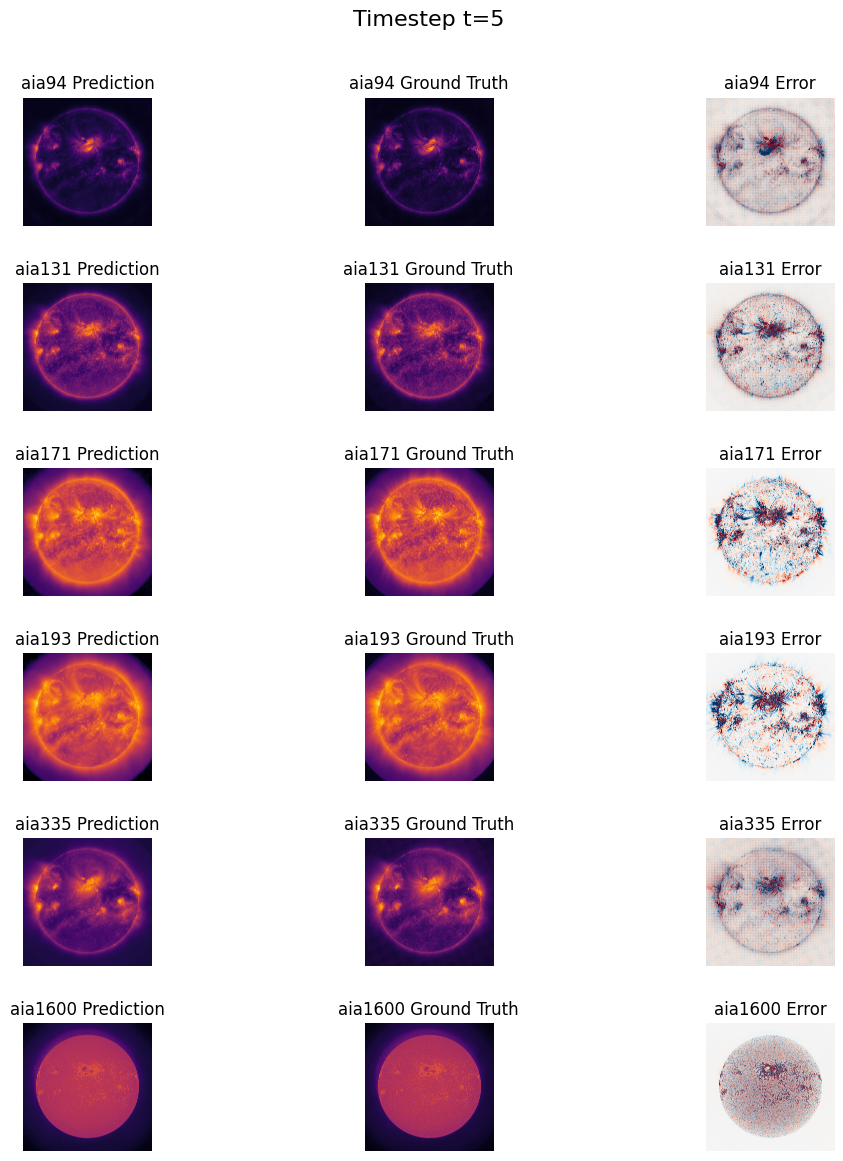

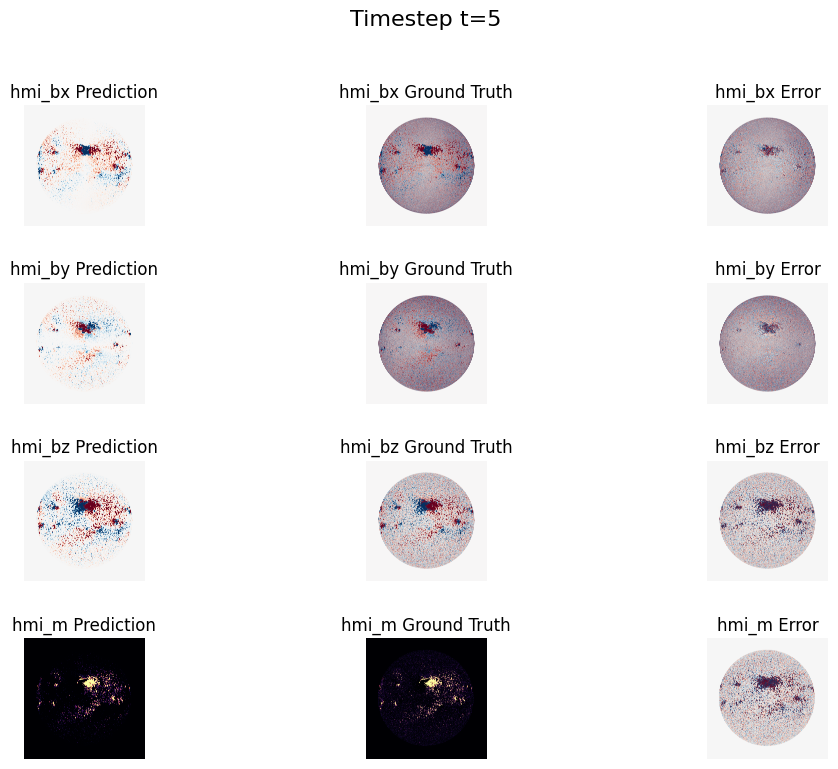

In [18]:
for t in [0, 5]:
    for label, group in groups.items():
        plot_timestep(ds, group, t=t, suffix=f"_{label}")

In [7]:
ds["hmi_bx"].values

array([[[[ 1.99257091e-01,  5.39775267e-02,  8.36800560e-02, ...,
          -3.33997518e-01, -2.86216825e-01,  2.97597293e-02],
         [-1.48111239e-01, -2.96806514e-01, -1.26254186e-01, ...,
          -4.50939655e-01, -5.78911662e-01, -1.68130264e-01],
         [-2.75107980e-01, -3.91369283e-01, -2.32715681e-01, ...,
          -5.99156320e-01, -6.76503718e-01, -5.25200665e-01],
         ...,
         [-3.61804031e-02,  7.69067416e-03,  6.84583932e-03, ...,
           1.50672182e-01, -8.16812292e-02, -1.85784772e-01],
         [ 1.14027858e-02, -4.67626490e-02,  7.37338811e-02, ...,
           6.58489391e-02, -5.94475381e-02, -2.57843107e-01],
         [ 6.87920675e-02,  6.41538296e-03,  1.63736448e-01, ...,
          -2.32860092e-02, -1.32805184e-01, -2.70935893e-03]],

        [[-1.96523368e-02, -8.88623744e-02, -8.72376468e-03, ...,
          -2.51991991e-02, -4.23174836e-02,  3.59762423e-02],
         [-2.35028476e-01, -2.44406730e-01, -7.77694136e-02, ...,
          -2.32396767e

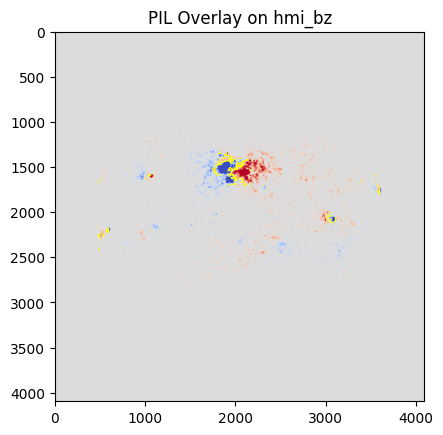

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

threshold = 5  # or try 30–100 depending on data
bz = ds["hmi_bz"][0,0].values  # your output
bz = gaussian_filter(bz, sigma=2)

sign = np.zeros_like(bz)

sign[bz > threshold] = 1
sign[bz < -threshold] = -1
valid = sign != 0

pil = np.zeros_like(sign, dtype=bool)

pil[:-1, :] |= (valid[:-1, :] & valid[1:, :] & (sign[:-1, :] != sign[1:, :]))
pil[:, :-1] |= (valid[:, :-1] & valid[:, 1:] & (sign[:, :-1] != sign[:, 1:]))

plt.imshow(bz, cmap="coolwarm", vmin=-500, vmax=500)
plt.contour(pil, colors='yellow', linewidths=0.5)
plt.title("PIL Overlay on hmi_bz")
plt.show()

In [23]:
print(bz.min(), bz.max())

-2786.9312 2684.211
